In [ ]:
import math
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_printoptions(precision=6, sci_mode=False)
print(f"PyTorch {torch.__version__} | device: CPU")

PyTorch 2.11.0+cpu | device: CPU


In [ ]:
z = torch.linspace(-6,6, 1201, requires_grad=True)

In [ ]:
relu_y = F.relu(z)
leaky_y = F.leaky_relu(z, negative_slope=0.01)
elu_y = F.elu(z, alpha=1.0)

In [ ]:
relu_grad = torch.autograd.grad(relu_y.sum(), z, retain_graph=True)[0]
leaky_grad = torch.autograd.grad(leaky_y.sum(), z, retain_graph=True)[0]


In PyTorch, every time you perform an operation on a tensor that has requires_grad=True (like your z tensor), PyTorch builds a "computational graph" in the background. This graph tracks the exact mathematical steps taken so it can run them in reverse later to calculate the gradients (backpropagation).

In [ ]:
elu_grad = torch.autograd.grad(elu_y.sum(), z)[0]

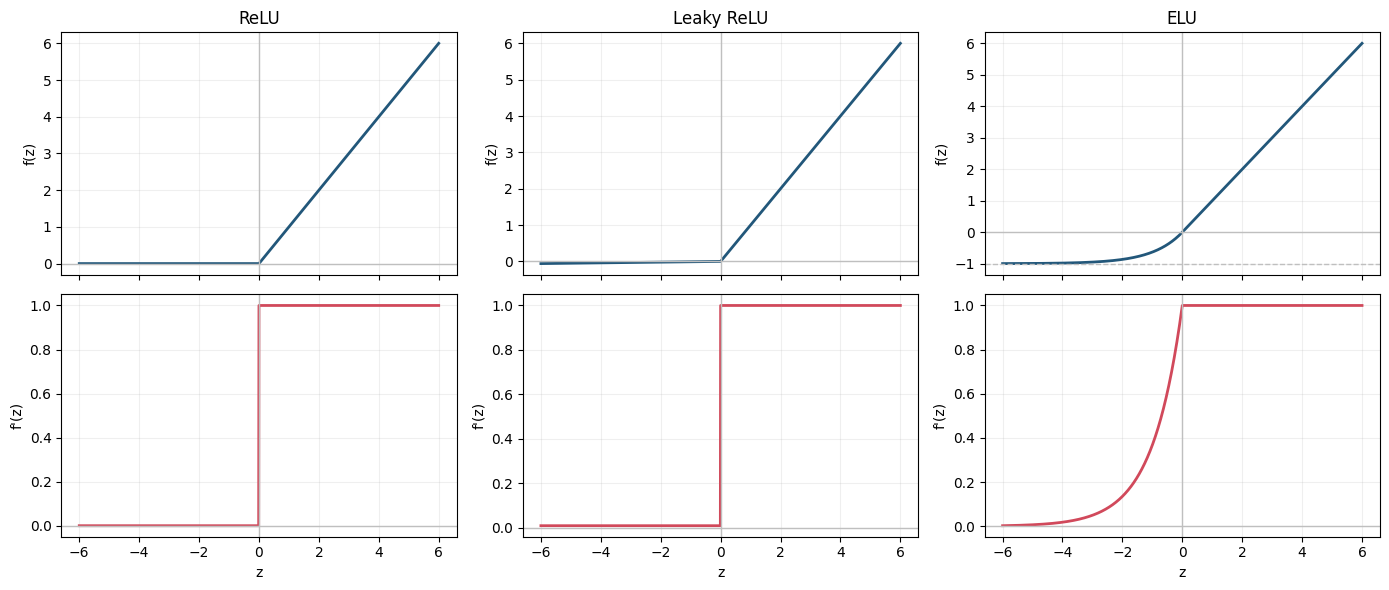

At z=0: ReLU'=1.00, Leaky ReLU'=1.00, ELU'=1.00
At z=-6.0: ReLU=0.000


In [ ]:
import matplotlib.pyplot as plt

names = ["ReLU", "Leaky ReLU", "ELU"]
outputs = [relu_y.detach(), leaky_y.detach(), elu_y.detach()]
grads = [relu_grad.detach(), leaky_grad.detach(), elu_grad.detach()]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for col, (name, out, grad) in enumerate(zip(names, outputs, grads)):
    # Plot Function
    axes[0, col].plot(z.detach(), out, color="#22577A", linewidth=2)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("f(z)")

    # Plot Gradient
    axes[1, col].plot(z.detach(), grad, color="#D1495B", linewidth=2)
    axes[1, col].set_ylabel("f'(z)")
    axes[1, col].set_xlabel("z")

    # Add crosshairs for visual clarity
    for ax in axes[:, col]:
        ax.axvline(0, color="0.75", linewidth=1)
        ax.axhline(0, color="0.75", linewidth=1) # <-- FIX: Added y=0 baseline
        ax.grid(alpha=0.2)

# ELU specific asymptote
axes[0, 2].axhline(-1.0, color="0.75", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

# FIX: Cleaned up the `0*0` index to properly reference the first element
center = len(z) // 2
print(f"At z=0: ReLU'={relu_grad[center].item():.2f}, "
      f"Leaky ReLU'={leaky_grad[center].item():.2f}, ELU'={elu_grad[center].item():.2f}")
print(f"At z={z[0].item():.1f}: ReLU={relu_y[0].item():.3f}")

### Check for understanding

Ask students to answer aloud:

1. Why can a ReLU neuron "die" during training, and why can't it recover on its own once it does?
2. How does Leaky ReLU's gradient at $z<0$ differ from ReLU's, and why does that matter?
3. Why is ELU smooth at $z=0$ while ReLU and Leaky ReLU have a kink there?


### 1. Why a ReLU Neuron "Dies" and Cannot Recover

**Why it dies:**
A ReLU neuron "dies" when a large error gradient causes a massive weight update during backpropagation. This large update can shift the neuron's weights and bias so far that the pre-activation sum `z = Wx + b` becomes strictly negative for **all** inputs in your training dataset. Because ReLU outputs `0` for any negative input, the neuron is effectively turned "off."

**Why it cannot recover:**
Once `z < 0` for all inputs, the neuron is stuck because the derivative (gradient) of ReLU for negative inputs is exactly `0`. During backpropagation, neural networks use the chain rule to update weights, which involves multiplying by the activation function's local gradient. If that local gradient is `0`, the entire weight update becomes `0`. The neuron stops learning completely and will never update its weights to become positive again.

---

### 2. Leaky ReLU's Gradient Difference and Its Importance

**How it differs:**
For negative inputs (`z < 0`), standard ReLU has a gradient of exactly `0`. Leaky ReLU, however, introduces a small, non-zero slope (often `alpha = 0.01`). This means its gradient for negative inputs is a small constant instead of zero.

**Why it matters:**
This small non-zero gradient is the exact solution to the "dying ReLU" problem. Because the gradient never drops entirely to zero, backpropagation can still flow through the neuron even when it outputs a negative value. The weights will continue to receive small updates, allowing a "dead" neuron the chance to eventually adjust its weights and recover into the active (positive) region.

---

### 3. The Smoothness of ELU vs. Kinks in ReLU variants

**The Kink in ReLU/Leaky ReLU:**
Both ReLU and Leaky ReLU are piecewise linear functions. At exactly `z = 0`, their slopes abruptly change. For example, standard ReLU instantly snaps from a slope of `0` to a slope of `1`. This sudden, sharp transition creates a "kink," meaning the function is not differentiable at exactly `z = 0`.

**The Smoothness of ELU:**
ELU (Exponential Linear Unit) eliminates this kink by using an exponential curve for negative values instead of a straight line.
* For `z >= 0`, ELU is simply `f(z) = z` (gradient is `1`).
* For `z < 0`, ELU is defined as `f(z) = alpha * (e^z - 1)`.

If we look at the derivative of the negative side, it is `alpha * e^z`. As `z` approaches `0` from the negative side, `alpha * e^0` equals `alpha`. When the hyperparameter `alpha` is set to `1.0`, the gradient smoothly approaches `1` from the left, which perfectly matches the gradient of `1` on the right side. Because the gradients match from both directions, the transition is seamless, making the function continuously differentiable and smooth at `z = 0`. This smoothness can help gradient descent converge faster by avoiding oscillations around the origin.

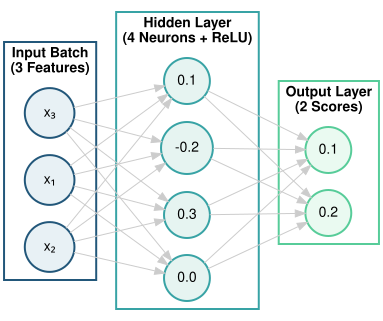

In [ ]:
from graphviz import Digraph
from IPython.display import display

# Create a directed graph
dot = Digraph(node_attr={'shape': 'circle', 'style': 'filled', 'fontname': 'Helvetica'})
dot.attr(rankdir='LR', splines='line')

# --- Input Layer ---
with dot.subgraph(name='cluster_0') as c:
    c.attr(label='Input Batch\n(3 Features)', color='#22577A', fontname='Helvetica-Bold', penwidth='2')
    c.node_attr.update(fillcolor='#e8f1f5', color='#22577A', penwidth='2')
    c.node('x1', 'x₁')
    c.node('x2', 'x₂')
    c.node('x3', 'x₃')

# --- Hidden Layer ---
with dot.subgraph(name='cluster_1') as c:
    c.attr(label='Hidden Layer\n(4 Neurons + ReLU)', color='#38A3A5', fontname='Helvetica-Bold', penwidth='2')
    c.node_attr.update(fillcolor='#e6f4f1', color='#38A3A5', penwidth='2')
    c.node('h0', '0.1') #0.1, -0.2, 0.3, 0.0
    c.node('h1', '-0.2')
    c.node('h2', '0.3')
    c.node('h3', '0.0')

# --- Output Layer ---
with dot.subgraph(name='cluster_2') as c:
    c.attr(label='Output Layer\n(2 Scores)', color='#57CC99', fontname='Helvetica-Bold', penwidth='2')
    c.node_attr.update(fillcolor='#eafaf1', color='#57CC99', penwidth='2')
    c.node('y1', '0.1')  #([0.1, 0.2])
    c.node('y2', '0.2')

# --- Connect the layers ---
for i in ['x1', 'x2', 'x3']:
    for h in ['h0', 'h1', 'h2', 'h3']:
        dot.edge(i, h, color='gray80')

for h in ['h0', 'h1', 'h2', 'h3']:
    for y in ['y1', 'y2']:
        dot.edge(h, y, color='gray80')

# Display the graph in Colab
display(dot)

In [ ]:
# --- Input (A "batch" of 3 samples, 3 features each) ---
# We use multiple samples now so we can see how a neuron behaves across different inputs
x = torch.tensor([[ 0.5, -1.0,  2.0],
                  [-1.5,  2.0, -1.0],
                  [ 1.0,  0.5, -0.5]])

# --- Hidden layer (3 → 4 neurons) ---
W_hidden = torch.tensor([[ 0.2, -0.5,  0.1,  0.8],
                         [ 0.4,  0.3, -0.7,  0.2],
                         [-0.1,  0.6,  0.5, -0.3]])

b_hidden = torch.tensor([0.1, -0.2, 0.3, 0.0])

# Linear transformation: z = xW + b
z_hidden = x @ W_hidden + b_hidden

# Apply ReLU on hidden layer
a_hidden = F.relu(z_hidden)

# --- Output layer (4 → 2 neurons) ---
W_out = torch.tensor([[ 0.3, -0.4],
                      [ 0.5,  0.1],
                      [-0.2,  0.6],
                      [ 0.7, -0.3]])

b_out = torch.tensor([0.1, 0.2])

output = a_hidden @ W_out + b_out

print("Hidden (after ReLU):\n", a_hidden)
print("-" * 40)

#Finding Dead Neurons
print("How to inspect a single neuron across our batch of 3 samples:")

# Remember: Rows = Samples, Columns = Neurons
# Let's look at just the first neuron (Column index 0)
neuron_0_acts = a_hidden[:, 0]
print("Neuron 0 activations: ", neuron_0_acts)

# We can easily check which inputs caused this neuron to output 0
is_zero = (neuron_0_acts == 0)
print("Is Neuron 0 output zero?:", is_zero)

# We can also check if the neuron is COMPLETELY dead
# (meaning it output 0 for ALL samples in the batch)
is_completely_dead = torch.all(neuron_0_acts == 0).item()
print("Is Neuron 0 completely dead for this batch?:", is_completely_dead)

Hidden (after ReLU):
 tensor([[0.000000, 0.450000, 2.050000, 0.000000],
        [0.700000, 0.550000, 0.000000, 0.000000],
        [0.550000, 0.000000, 0.000000, 1.050000]])
----------------------------------------
How to inspect a single neuron across our batch of 3 samples:
Neuron 0 activations:  tensor([0.000000, 0.700000, 0.550000])
Is Neuron 0 output zero?: tensor([ True, False, False])
Is Neuron 0 completely dead for this batch?: False


## Your Turn: Spot the Dead Neuron

In the previous example, you saw how a **ReLU** neuron switches "off" (`z <= 0`) or "on" (`z > 0`) depending on the specific input data in our small batch of 3 samples. Because normal data usually has a good mix of values, most neurons will turn on for at least *some* of the inputs in a batch, meaning they aren't entirely "dead".

Let's test this on a much larger scale. First, we will test a batch of 100 samples with values ranging from -2 to 2 to confirm our neurons are healthy. Then, we will drastically shift the data to see if we can force a neuron to "die"!

**Task:**
1. Compute the pre-activations (`z_hidden`) and apply `F.relu()` to get the activations (`a_hidden`) for the large batch `x1` (values -2 to 2).
2. For each of the **4 hidden neurons** (the columns of `a_hidden`), check whether **every single value** in its column is exactly `0` (hint: `torch.all(a_hidden[:, i] == 0)`). Confirm none are fully dead here.
3. Now shift the input batch so the values are strictly negative: `x2 = x1 - 5.0` (shifting the range to -7 to -3). Recompute `z_hidden2` and `a_hidden2` for `x2` using the exact same weights and biases.
4. Run the "all zero" check again. Some neurons should now be permanently `0` on this new range.
   *Question:* Look at the weights in `W_hidden`. If a neuron's weights are mostly positive, what happens to the sum `z = xW + b` when the inputs (`x`) become strongly negative?

This is the real danger of the "dying ReLU" problem: a neuron can look perfectly healthy on the training data you tested, but become permanently disabled if the input data shifts to a new range in the real world (data drift), or if a large gradient update suddenly shifts its weights!

In [ ]:
import torch
import torch.nn.functional as F

# --- Network Parameters (3 inputs, 4 hidden neurons) ---
W_hidden = torch.tensor([[ 0.2, -0.5,  0.1,  0.8],
                         [ 0.4,  0.3, -0.7,  0.2],
                         [-0.1,  0.6,  0.5, -0.3]])

b_hidden = torch.tensor([0.1, -0.2, 0.3, 0.0])

# ==========================================
# Part A: Check original input range
# ==========================================
# Create a batch of 100 samples with values ranging from -2 to 2
x1 = torch.linspace(-2, 2, 100).unsqueeze(1).repeat(1, 3)

# TODO: 1. Compute z_hidden and apply ReLU to get a_hidden for x1
# z_hidden = ...
# a_hidden = ...

print("Part A: Checking dead neurons on original range (-2 to 2)")
# TODO: 2. Loop over the 4 hidden neurons (columns of a_hidden)
# and print if they are completely dead.
# Hint: Use torch.all(a_hidden[:, i] == 0)


# ==========================================
# Part B: Shift the input range and check again
# ==========================================
# Shift the inputs so they are strictly negative
x2 = x1 - 5.0

# TODO: 3. Compute z_hidden2 and a_hidden2 for the new shifted input x2
# z_hidden2 = ...
# a_hidden2 = ...

print("\nPart B: Checking dead neurons on shifted range (-7 to -3)")
# TODO: 4. Loop over the 4 hidden neurons again and print if they are dead.
# Which one is now permanently dead on this range?

Part A: Checking dead neurons on original range (-2 to 2)

Part B: Checking dead neurons on shifted range (-7 to -3)


### What happens when the real world changes?
In Part A, our neurons looked healthy! But in the real world, the data you feed into a model might shift over time (this is called **Data Drift**).

For example, what if a sensor recalibrates, and suddenly all your input values become strongly negative? Let's shift our input data range from `[-2 to 2]` down to `[-7 to -3]` and see how our previously healthy neurons react to this new data.

# Solution: Dead Neuron

In [ ]:
# --- Network Parameters (3 inputs, 4 hidden neurons) ---
W_hidden = torch.tensor([[ 0.2, -0.5,  0.1,  0.8],
                         [ 0.4,  0.3, -0.7,  0.2],
                         [-0.1,  0.6,  0.5, -0.3]])

b_hidden = torch.tensor([0.1, -0.2, 0.3, 0.0])

# ==========================================
# Part A: Check original input range
# ==========================================
x1 = torch.linspace(-2, 2, 100).unsqueeze(1).repeat(1, 3)

# 1. Compute z_hidden and apply ReLU
z_hidden = x1 @ W_hidden + b_hidden
a_hidden = F.relu(z_hidden)

print("Part A: Checking dead neurons on original range (-2 to 2)")
# 2. Loop over the 4 hidden neurons (columns)
for i in range(a_hidden.shape[1]):
    is_dead = torch.all(a_hidden[:, i] == 0).item()
    print(f"Neuron {i} completely dead? {is_dead}")

# ==========================================
# Part B: Shift the input range and check again
# ==========================================
x2 = x1 - 5.0

# 3. Compute z_hidden2 and a_hidden2 for x2
z_hidden2 = x2 @ W_hidden + b_hidden
a_hidden2 = F.relu(z_hidden2)

print("\nPart B: Checking dead neurons on shifted range (-7 to -3)")
# 4. Loop over the 4 hidden neurons again
for i in range(a_hidden2.shape[1]):
    is_dead = torch.all(a_hidden2[:, i] == 0).item()
    print(f"Neuron {i} completely dead? {is_dead}")

Part A: Checking dead neurons on original range (-2 to 2)
Neuron 0 completely dead? False
Neuron 1 completely dead? False
Neuron 2 completely dead? False
Neuron 3 completely dead? False

Part B: Checking dead neurons on shifted range (-7 to -3)
Neuron 0 completely dead? True
Neuron 1 completely dead? True
Neuron 2 completely dead? False
Neuron 3 completely dead? True


## Softmax -- a different kind of activation

All five functions above take **one number in, one number out**. Softmax is different:
it takes a **vector of scores** (one per class) and turns them into **probabilities that
sum to 1**.

**Formula:** for a vector of scores $z = (z_1, z_2, ..., z_k)$:
$$\text{softmax}(z)_i = \dfrac{e^{z_i}}{\sum_j e^{z_j}}$$

**Where it's used:** only at the **output layer**, for multi-class classification
problems (e.g. "is this image a cat, dog, or bird?") -- never in hidden layers.

**Why exponentials?** Exponentiating first (before normalizing) makes larger scores
dominate more strongly, and guarantees every output is positive -- both properties are
needed for the result to be interpreted as a probability distribution.

Pro-Tip for Students: In this example, we have a single 1D list of scores, so we use dim=0 to calculate the probabilities along that single dimension. In real neural networks, you will process data in batches (a 2D matrix where rows are samples and columns are class scores). When using batches, you must use dim=1 so that PyTorch calculates the Softmax across the columns (ensuring each individual sample's probabilities sum to 1).

In [ ]:
import torch.nn as nn

# 1. Initialize the built-in Softmax module
softmax_module = nn.Softmax(dim=0)

logits = torch.tensor([2.0, 1.0, 0.1])

# 2. Pass the logits through the module
mine = softmax_module(logits)

print("module_softmax:", mine, "sum =", mine.sum().item())

module_softmax: tensor([0.659001, 0.242433, 0.098566]) sum = 1.0000001192092896


Cat    raw score z =  2.00   ->   probability = 0.659
Dog    raw score z =  1.00   ->   probability = 0.242
Bird   raw score z =  0.10   ->   probability = 0.099


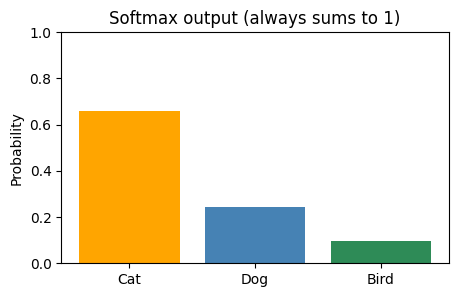


Sum of probabilities: 1.0000001192092896


In [ ]:
# Example: raw output scores from the network for 3 classes
classes = ['Cat', 'Dog', 'Bird']

# Convert the raw scores to a PyTorch tensor
scores = torch.tensor([2.0, 1.0, 0.1])   # these are the z's

# 1. Initialize the built-in Softmax module (Option 2)
softmax_module = nn.Softmax(dim=0)

# 2. Pass the scores through the module
probs = softmax_module(scores)

# Iterate and print the results (using .item() to extract the Python number)
for c, s, p in zip(classes, scores, probs):
    print(f'{c:5s}  raw score z = {s.item():5.2f}   ->   probability = {p.item():.3f}')

# Plotting
plt.figure(figsize=(5, 3))
# Use .detach().numpy() to safely convert the PyTorch tensor back to NumPy for Matplotlib
plt.bar(classes, probs.detach().numpy(), color=['orange', 'steelblue', 'seagreen'])
plt.ylim(0, 1)
plt.ylabel('Probability')
plt.title('Softmax output (always sums to 1)')
plt.show()

# Verify the sum
print('\nSum of probabilities:', probs.sum().item())